<a href="https://colab.research.google.com/github/jrdndj/ImproVisAR-PilotPlots/blob/main/ImproVisAR_keypressheatmap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

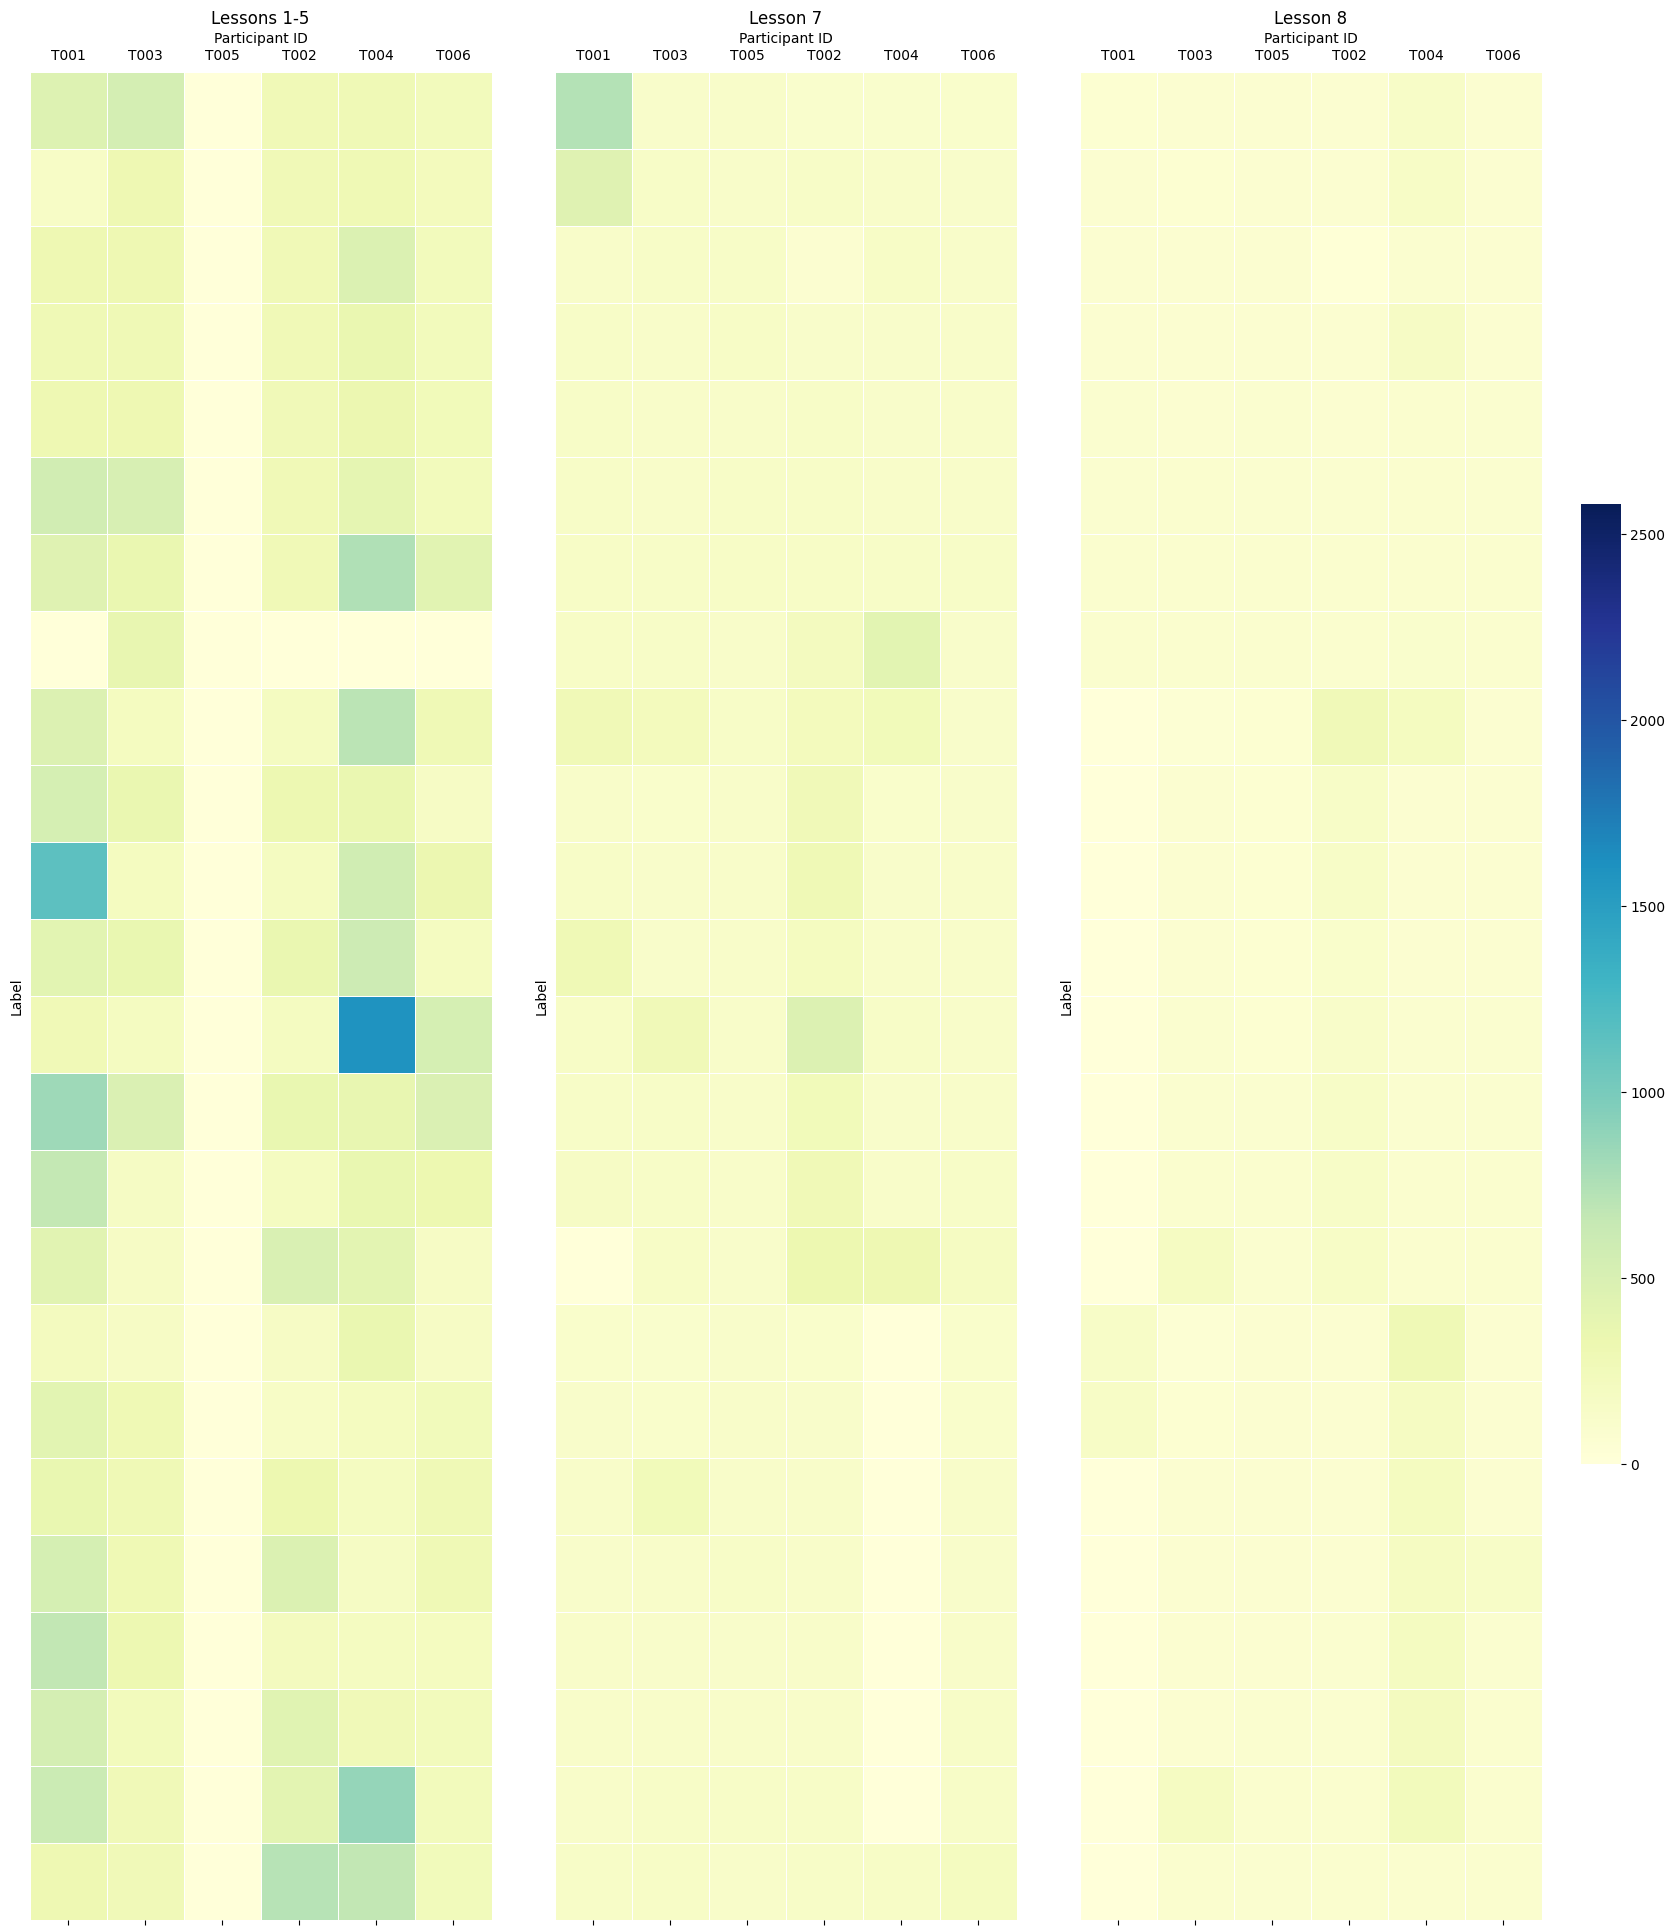

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Load the data
csv_filename = "keypress_summary_for_heatmap.csv"
df = pd.read_csv(csv_filename)

# Ensure sorting
df["Lesson"] = df["Lesson"].astype(int)
df["Task"] = df["Task"].astype(int)

# Define participant sorting: AR = odd IDs, Non-AR = even IDs
participants = sorted(df["ID"].unique(), key=lambda x: (int(x[1:]) % 2 == 0, int(x[1:])))

# Create simplified task labels
df["Label"] = df.apply(lambda row: f"D{row['Day'][3]}L{row['Lesson']}T{row['Task']}", axis=1)

# Sort by Day, Lesson, then Task
df = df.sort_values(by=["Day", "Lesson", "Task"])

# Pivot the data
pivot_df = df.pivot_table(index="Label", columns="ID", values="Keypress_count", aggfunc="sum", fill_value=0)

# Reindex columns based on AR/Non-AR order
pivot_df = pivot_df[participants]

# Create subsets for the three heatmaps using regex patterns safely
heatmap1 = pivot_df[pivot_df.index.to_series().str.contains(r"^D1L[1-5]T")]
heatmap2 = pivot_df[pivot_df.index.to_series().str.contains(r"L7T")]
heatmap3 = pivot_df[pivot_df.index.to_series().str.contains(r"L8T")]

# Determine shared color scale range
vmin = pivot_df.min().min()
vmax = pivot_df.max().max()

# Plot heatmaps side by side with a single colorbar
num_rows = max(len(heatmap1), len(heatmap2), len(heatmap3))
fig, axes = plt.subplots(1, 3, figsize=(20, num_rows), sharey=True)
cbar_ax = fig.add_axes([.91, .3, .02, .4])  # shared colorbar position

for ax in axes:
    ax.xaxis.set_label_position('top')
    ax.tick_params(axis='x', labelbottom=False, labeltop=True, labelrotation=0)

sns.heatmap(heatmap1, cmap="YlGnBu", ax=axes[0], cbar=True, cbar_ax=cbar_ax,
            vmin=vmin, vmax=vmax, xticklabels=True, yticklabels=True, square=True,
            linewidths=0.5, linecolor='white')
axes[0].set_title("Lessons 1-5")
axes[0].set_xlabel("Participant ID")

sns.heatmap(heatmap2, cmap="YlGnBu", ax=axes[1], cbar=False,
            vmin=vmin, vmax=vmax, xticklabels=True, yticklabels=False, square=True,
            linewidths=0.5, linecolor='white')
axes[1].set_title("Lesson 7")
axes[1].set_xlabel("Participant ID")

sns.heatmap(heatmap3, cmap="YlGnBu", ax=axes[2], cbar=False,
            vmin=vmin, vmax=vmax, xticklabels=True, yticklabels=False, square=True,
            linewidths=0.5, linecolor='white')
axes[2].set_title("Lesson 8")
axes[2].set_xlabel("Participant ID")

plt.subplots_adjust(wspace=0.05)
plt.show()


how about we pivot it

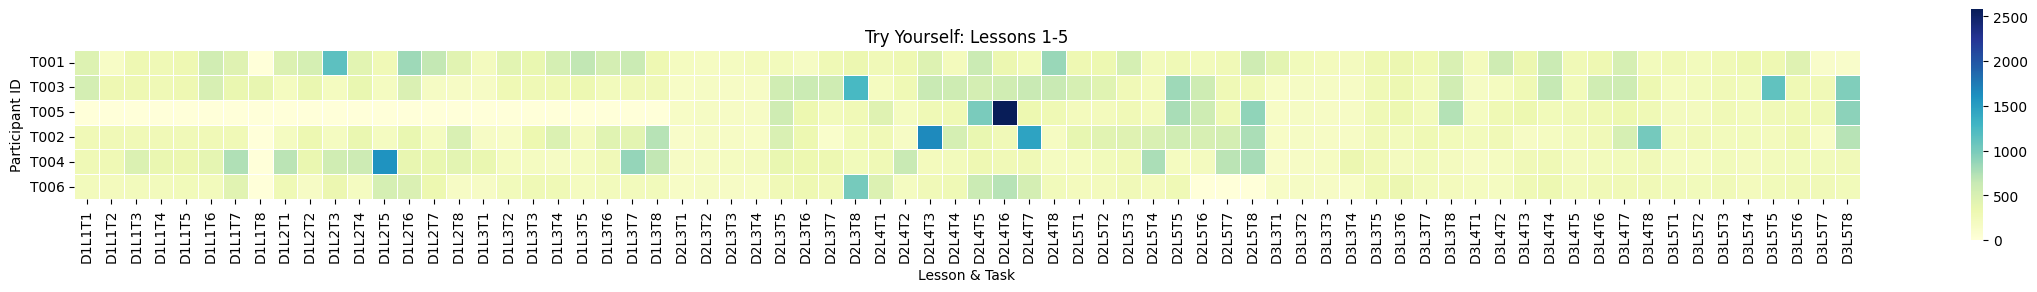

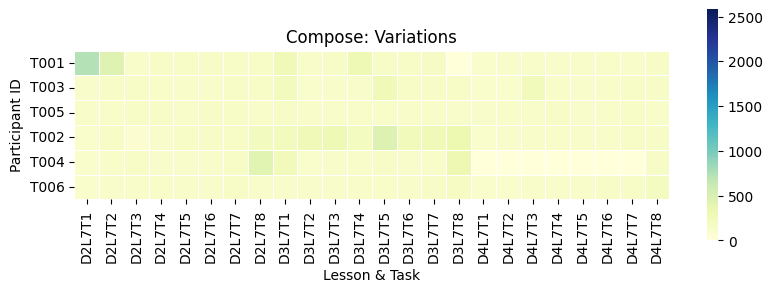

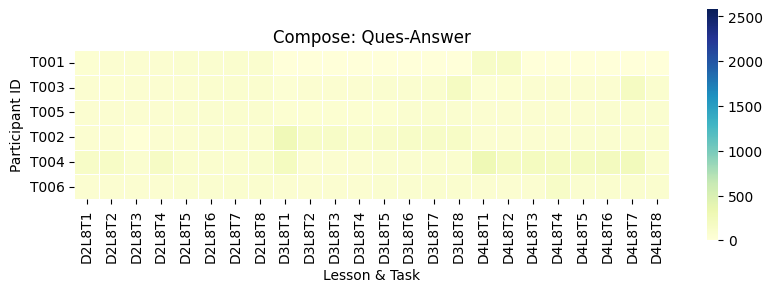

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Load the data
csv_filename = "keypress_summary_for_heatmap.csv"
df = pd.read_csv(csv_filename)

# Ensure sorting
df["Lesson"] = df["Lesson"].astype(int)
df["Task"] = df["Task"].astype(int)

# Define participant sorting: AR = odd IDs, Non-AR = even IDs
participants = sorted(df["ID"].unique(), key=lambda x: (int(x[1:]) % 2 == 0, int(x[1:])))

# Create simplified task labels
df["Label"] = df.apply(lambda row: f"D{row['Day'][3]}L{row['Lesson']}T{row['Task']}", axis=1)

# Sort by Day, Lesson, then Task
df = df.sort_values(by=["Day", "Lesson", "Task"])

# Pivot the full data: Participant IDs as rows, labels as columns
pivot_full = df.pivot_table(index="ID", columns="Label", values="Keypress_count", aggfunc="sum", fill_value=0)

# Reindex rows based on AR/Non-AR order
pivot_full = pivot_full.loc[participants]

# Filter columns for subsets based on full ranges
columns_l1_5 = [col for col in pivot_full.columns if re.match(r"D[1-3]L[1-5]T[1-8]?$", col)]
columns_l7 = [col for col in pivot_full.columns if re.match(r"D[2-4]L7T[1-8]$", col)]
columns_l8 = [col for col in pivot_full.columns if re.match(r"D[2-4]L8T[1-8]$", col)]

# Sort columns
columns_l1_5 = sorted(columns_l1_5)
columns_l7 = sorted(columns_l7)
columns_l8 = sorted(columns_l8)

# Subset data
heatmap1 = pivot_full[columns_l1_5]
heatmap2 = pivot_full[columns_l7]
heatmap3 = pivot_full[columns_l8]

# Determine shared color scale range
vmin = pivot_full.min().min()
vmax = pivot_full.max().max()

# Plot heatmaps with one per figure
figsize1 = (len(heatmap1.columns) * 0.4, len(heatmap1.index) * 0.5)
plt.figure(figsize=figsize1)
sns.heatmap(heatmap1, cmap="YlGnBu", vmin=vmin, vmax=vmax,
            xticklabels=True, yticklabels=True, square=True, linewidths=0.5, linecolor='white')
plt.title("Try Yourself: Lessons 1-5")
plt.xlabel("Lesson & Task")
plt.ylabel("Participant ID")
plt.xticks(rotation=90)
plt.show()

figsize2 = (len(heatmap2.columns) * 0.4, len(heatmap2.index) * 0.5)
plt.figure(figsize=figsize2)
sns.heatmap(heatmap2, cmap="YlGnBu", vmin=vmin, vmax=vmax,
            xticklabels=True, yticklabels=True, square=True, linewidths=0.5, linecolor='white')
plt.title("Compose: Variations")
plt.xlabel("Lesson & Task")
plt.ylabel("Participant ID")
plt.xticks(rotation=90)
plt.show()

figsize3 = (len(heatmap3.columns) * 0.4, len(heatmap3.index) * 0.5)
plt.figure(figsize=figsize3)
sns.heatmap(heatmap3, cmap="YlGnBu", vmin=vmin, vmax=vmax,
            xticklabels=True, yticklabels=True, square=True, linewidths=0.5, linecolor='white')
plt.title("Compose: Ques-Answer")
plt.xlabel("Lesson & Task")
plt.ylabel("Participant ID")
plt.xticks(rotation=90)
plt.show()


good progress. now im gonna add different color bars just to see whats obvious


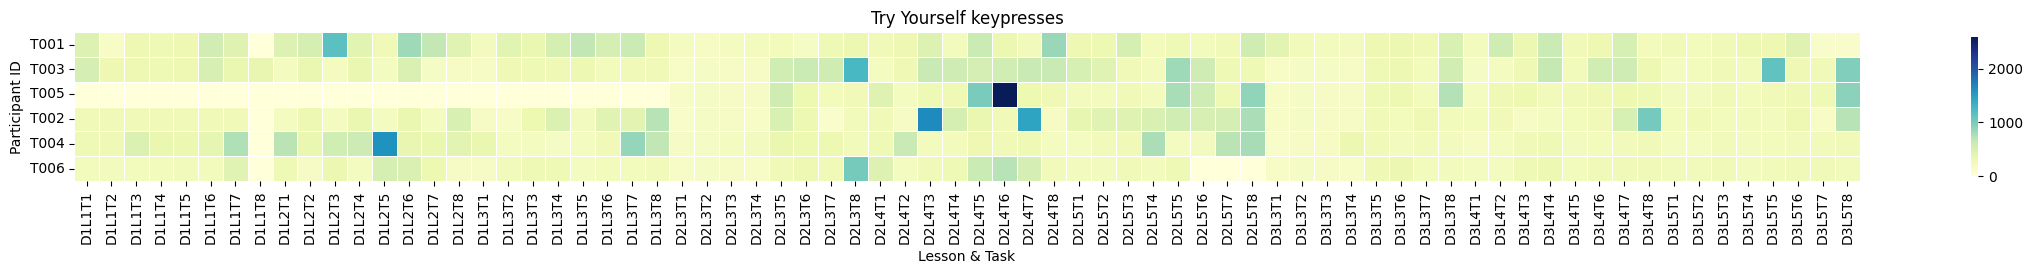

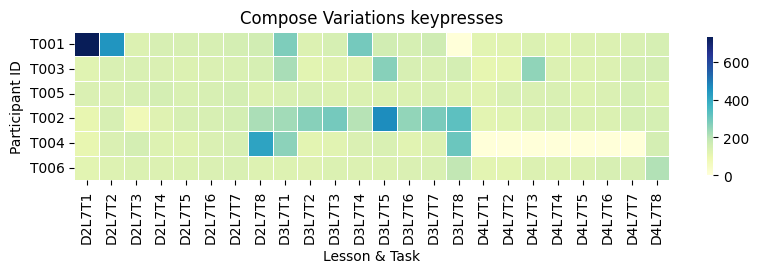

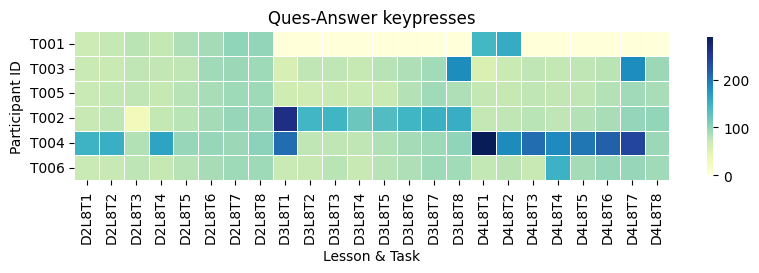

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Load the data
csv_filename = "keypress_summary_for_heatmap.csv"
df = pd.read_csv(csv_filename)

# Ensure sorting
df["Lesson"] = df["Lesson"].astype(int)
df["Task"] = df["Task"].astype(int)

# Define participant sorting: AR = odd IDs, Non-AR = even IDs
participants = sorted(df["ID"].unique(), key=lambda x: (int(x[1:]) % 2 == 0, int(x[1:])))

# Create simplified task labels
df["Label"] = df.apply(lambda row: f"D{row['Day'][3]}L{row['Lesson']}T{row['Task']}", axis=1)

# Sort by Day, Lesson, then Task
df = df.sort_values(by=["Day", "Lesson", "Task"])

# Pivot the full data: Participant IDs as rows, labels as columns
pivot_full = df.pivot_table(index="ID", columns="Label", values="Keypress_count", aggfunc="sum", fill_value=0)

# Reindex rows based on AR/Non-AR order
pivot_full = pivot_full.loc[participants]

# Filter columns for subsets based on full ranges
columns_l1_5 = [col for col in pivot_full.columns if re.match(r"D[1-3]L[1-5]T[1-8]?$", col)]
columns_l7 = [col for col in pivot_full.columns if re.match(r"D[2-4]L7T[1-8]$", col)]
columns_l8 = [col for col in pivot_full.columns if re.match(r"D[2-4]L8T[1-8]$", col)]

# Sort columns
columns_l1_5 = sorted(columns_l1_5)
columns_l7 = sorted(columns_l7)
columns_l8 = sorted(columns_l8)

# Subset data
heatmap1 = pivot_full[columns_l1_5]
heatmap2 = pivot_full[columns_l7]
heatmap3 = pivot_full[columns_l8]

# Plot heatmaps with one per figure and individual colorbars (independent scales)
figsize1 = (len(heatmap1.columns) * 0.4, len(heatmap1.index) * 0.5)
plt.figure(figsize=figsize1)
sns.heatmap(heatmap1, cmap="YlGnBu", cbar_kws={'shrink': 0.6},
            xticklabels=True, yticklabels=True, square=True, linewidths=0.5, linecolor='white')
plt.title("Try Yourself keypresses")
plt.xlabel("Lesson & Task")
plt.ylabel("Participant ID")
plt.xticks(rotation=90)
plt.show()

figsize2 = (len(heatmap2.columns) * 0.4, len(heatmap2.index) * 0.5)
plt.figure(figsize=figsize2)
sns.heatmap(heatmap2, cmap="YlGnBu", cbar_kws={'shrink': 0.6},
            xticklabels=True, yticklabels=True, square=True, linewidths=0.5, linecolor='white')
plt.title("Compose Variations keypresses")
plt.xlabel("Lesson & Task")
plt.ylabel("Participant ID")
plt.xticks(rotation=90)
plt.show()

figsize3 = (len(heatmap3.columns) * 0.4, len(heatmap3.index) * 0.5)
plt.figure(figsize=figsize3)
sns.heatmap(heatmap3, cmap="YlGnBu", cbar_kws={'shrink': 0.6},
            xticklabels=True, yticklabels=True, square=True, linewidths=0.5, linecolor='white')
plt.title("Ques-Answer keypresses")
plt.xlabel("Lesson & Task")
plt.ylabel("Participant ID")
plt.xticks(rotation=90)
plt.show()
